# Part 1k: Data Augmentation Across Domains
**Author:** Kalhar Mayurbhai Patel (019140511)

Demonstrates data augmentation and classification for:
1. **Image** — standard transforms
2. **Text** — nlpaug
3. **Time Series** — jittering, scaling, window warping
4. **Tabular** — SMOTE, noise injection
5. **Audio/Speech** — time stretch, pitch shift

In [1]:
!pip install nlpaug audiomentations -q 2>/dev/null

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 9.2 MB/s eta 0:00:00


## 1. Image Augmentation (TF + PyTorch)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


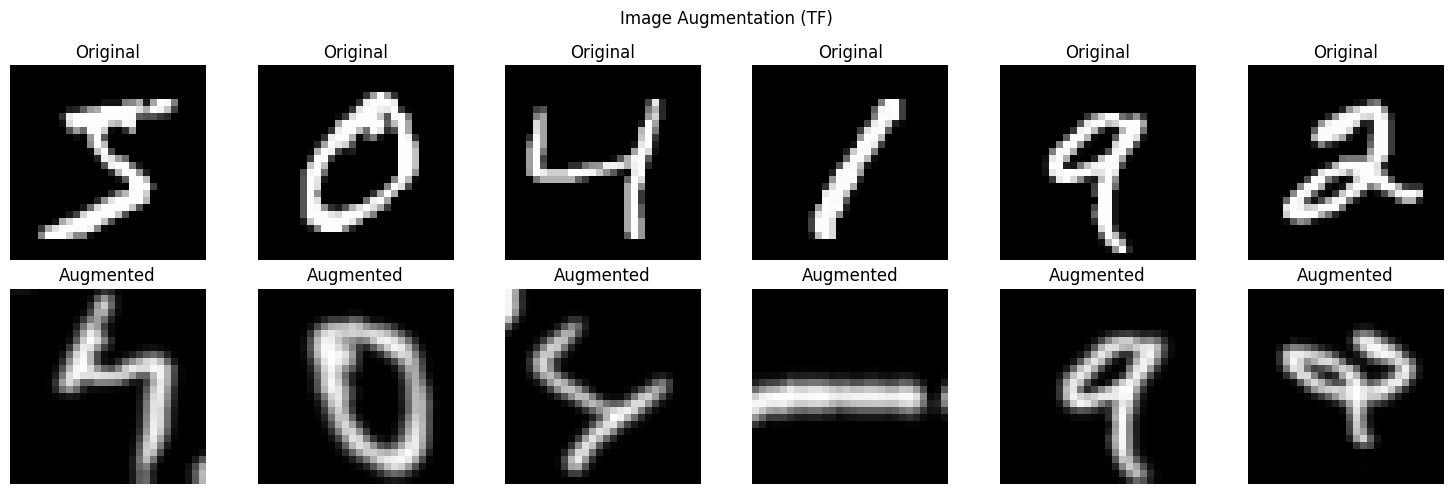

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

(X_train, y_train), _ = tf.keras.datasets.mnist.load_data()
X_train = X_train[:500].astype('float32') / 255.0
X_train = X_train[..., np.newaxis]

# TF augmentation
aug_layer = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
])

fig, axes = plt.subplots(2, 6, figsize=(15, 5))
for i in range(6):
    axes[0, i].imshow(X_train[i].squeeze(), cmap='gray'); axes[0, i].set_title('Original')
    axes[1, i].imshow(aug_layer(X_train[i:i+1])[0].numpy().squeeze(), cmap='gray')
    axes[1, i].set_title('Augmented')
for ax in axes.flat: ax.axis('off')
plt.suptitle('Image Augmentation (TF)'); plt.tight_layout(); plt.show()

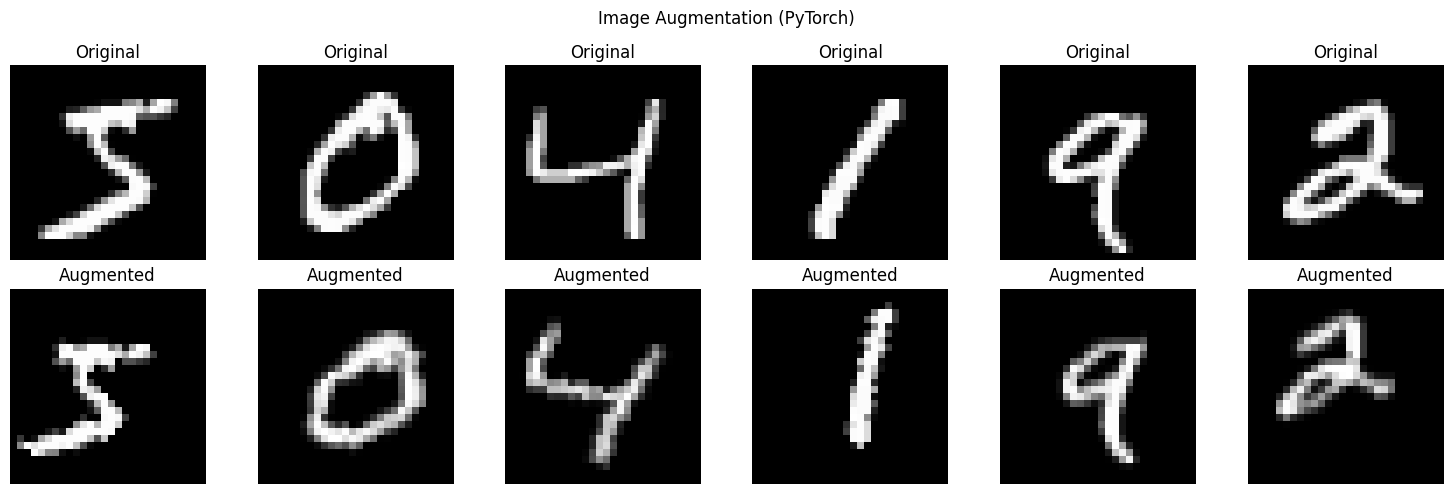

In [3]:
# PyTorch image augmentation
import torch
from torchvision import transforms

pt_aug = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomAffine(degrees=20, translate=(0.1, 0.1), scale=(0.85, 1.15)),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
    transforms.ToTensor(),
])

fig, axes = plt.subplots(2, 6, figsize=(15, 5))
for i in range(6):
    img = torch.FloatTensor(X_train[i].squeeze()).unsqueeze(0)
    axes[0, i].imshow(img.squeeze(), cmap='gray'); axes[0, i].set_title('Original')
    axes[1, i].imshow(pt_aug(img).squeeze(), cmap='gray'); axes[1, i].set_title('Augmented')
for ax in axes.flat: ax.axis('off')
plt.suptitle('Image Augmentation (PyTorch)'); plt.tight_layout(); plt.show()

## 2. Text Augmentation (nlpaug)

In [5]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')
import nlpaug.augmenter.word as naw
import nlpaug.augmenter.char as nac

text = "The quick brown fox jumps over the lazy dog near the riverbank."

# Synonym replacement
syn_aug = naw.SynonymAug(aug_src='wordnet')
# Random character insert
char_aug = nac.RandomCharAug(action='insert')

print("Original:", text)
print("Synonym: ", syn_aug.augment(text))
print("CharIns: ", char_aug.augment(text))

# Multiple augmentations
texts = [text] * 3
for t in texts:
    print("Aug:", syn_aug.augment(t))

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


Original: The quick brown fox jumps over the lazy dog near the riverbank.
Synonym:  ['The quick brown slyboots jumps terminated the otiose dog near the riverside.']
CharIns:  ['The qduicHk brown fox jumps ovCeTr the lazy dog Gne4ar the Zriverbman@k.']
Aug: ['The quick brown dodger jump over the lazy andiron skinny the riverbank.']
Aug: ['The warm brown charles james fox jumps complete the slothful dog near the riverbank.']
Aug: ['The quick brownness fox leap over the lazy dog nigh the riverside.']


## 3. Time Series Augmentation

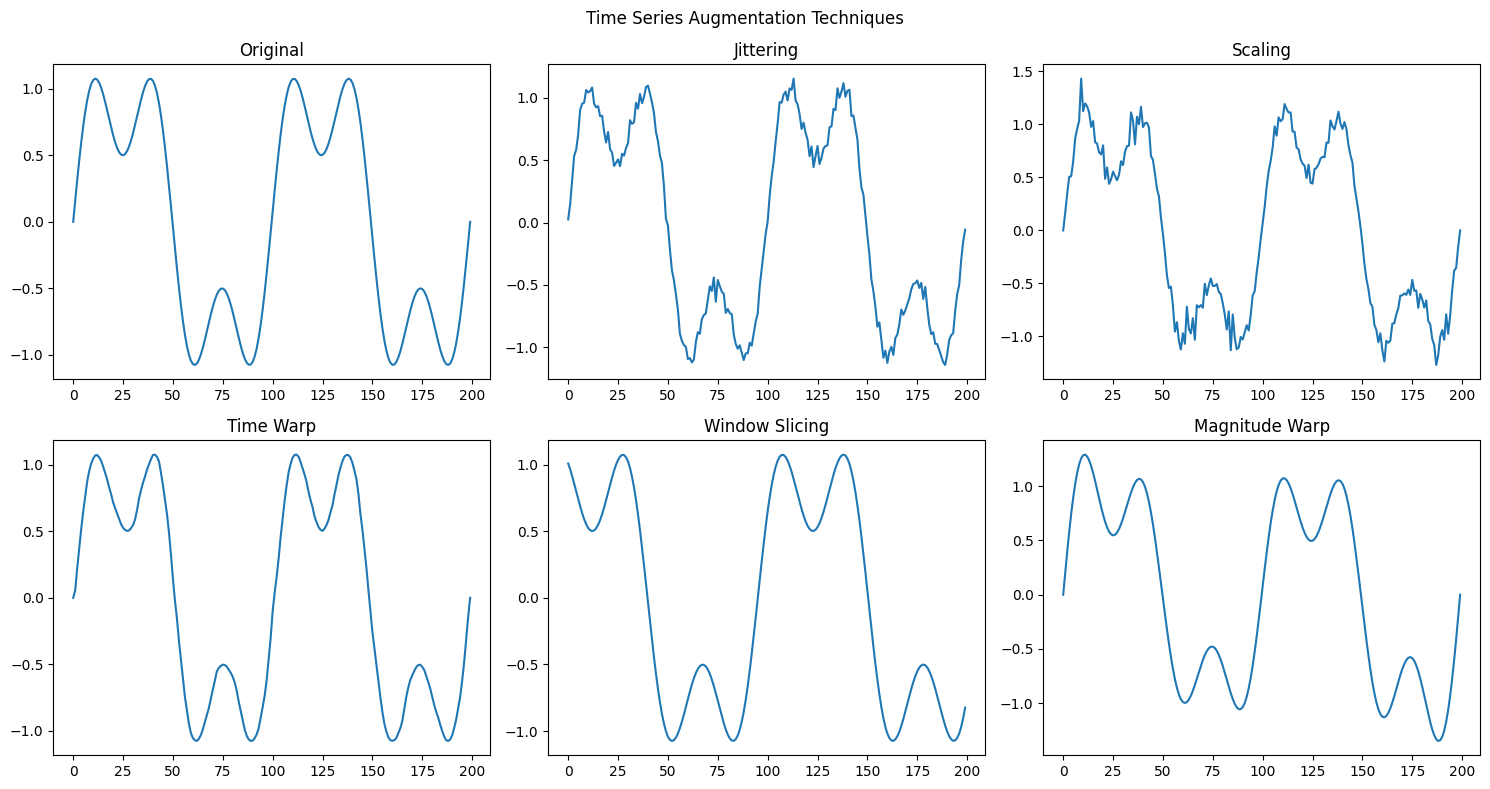

In [6]:
# Generate synthetic time series
np.random.seed(42)
t = np.linspace(0, 4*np.pi, 200)
ts_original = np.sin(t) + 0.5 * np.sin(3*t)

def jitter(x, sigma=0.05):
    return x + np.random.normal(0, sigma, x.shape)

def scaling(x, sigma=0.1):
    factor = np.random.normal(1, sigma, x.shape)
    return x * factor

def time_warp(x, sigma=0.2):
    distortion = np.cumsum(np.random.normal(1, sigma, len(x)))
    distortion = distortion / distortion[-1] * (len(x) - 1)
    return np.interp(np.arange(len(x)), distortion, x)

def window_slice(x, ratio=0.9):
    target_len = int(len(x) * ratio)
    start = np.random.randint(0, len(x) - target_len)
    return np.interp(np.linspace(0, target_len-1, len(x)),
                     np.arange(target_len), x[start:start+target_len])

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes[0,0].plot(ts_original); axes[0,0].set_title('Original')
axes[0,1].plot(jitter(ts_original)); axes[0,1].set_title('Jittering')
axes[0,2].plot(scaling(ts_original)); axes[0,2].set_title('Scaling')
axes[1,0].plot(time_warp(ts_original)); axes[1,0].set_title('Time Warp')
axes[1,1].plot(window_slice(ts_original)); axes[1,1].set_title('Window Slicing')
# Magnitude warping
mw = ts_original * np.interp(np.arange(len(ts_original)),
    np.linspace(0, len(ts_original), 5), np.random.normal(1, 0.2, 5))
axes[1,2].plot(mw); axes[1,2].set_title('Magnitude Warp')
plt.suptitle('Time Series Augmentation Techniques'); plt.tight_layout(); plt.show()

## 4. Tabular Data Augmentation (SMOTE + Noise)

In [7]:
from sklearn.datasets import make_classification
from collections import Counter

# Imbalanced dataset
X_tab, y_tab = make_classification(n_samples=1000, n_features=10, n_informative=5,
                                    weights=[0.9, 0.1], random_state=42)
print("Before augmentation:", Counter(y_tab))

# Method 1: Gaussian noise injection for minority class
minority_X = X_tab[y_tab == 1]
noise = np.random.normal(0, 0.1, minority_X.shape)
augmented = minority_X + noise
X_aug = np.vstack([X_tab, augmented])
y_aug = np.hstack([y_tab, np.ones(len(augmented))])
print("After noise injection:", Counter(y_aug.astype(int)))

# Method 2: SMOTE
try:
    from imblearn.over_sampling import SMOTE
    sm = SMOTE(random_state=42)
    X_sm, y_sm = sm.fit_resample(X_tab, y_tab)
    print("After SMOTE:", Counter(y_sm))
except ImportError:
    print("Install imbalanced-learn for SMOTE: pip install imbalanced-learn")

Before augmentation: Counter({np.int64(0): 896, np.int64(1): 104})
After noise injection: Counter({np.int64(0): 896, np.int64(1): 208})
After SMOTE: Counter({np.int64(0): 896, np.int64(1): 896})


## 5. Audio/Speech Augmentation

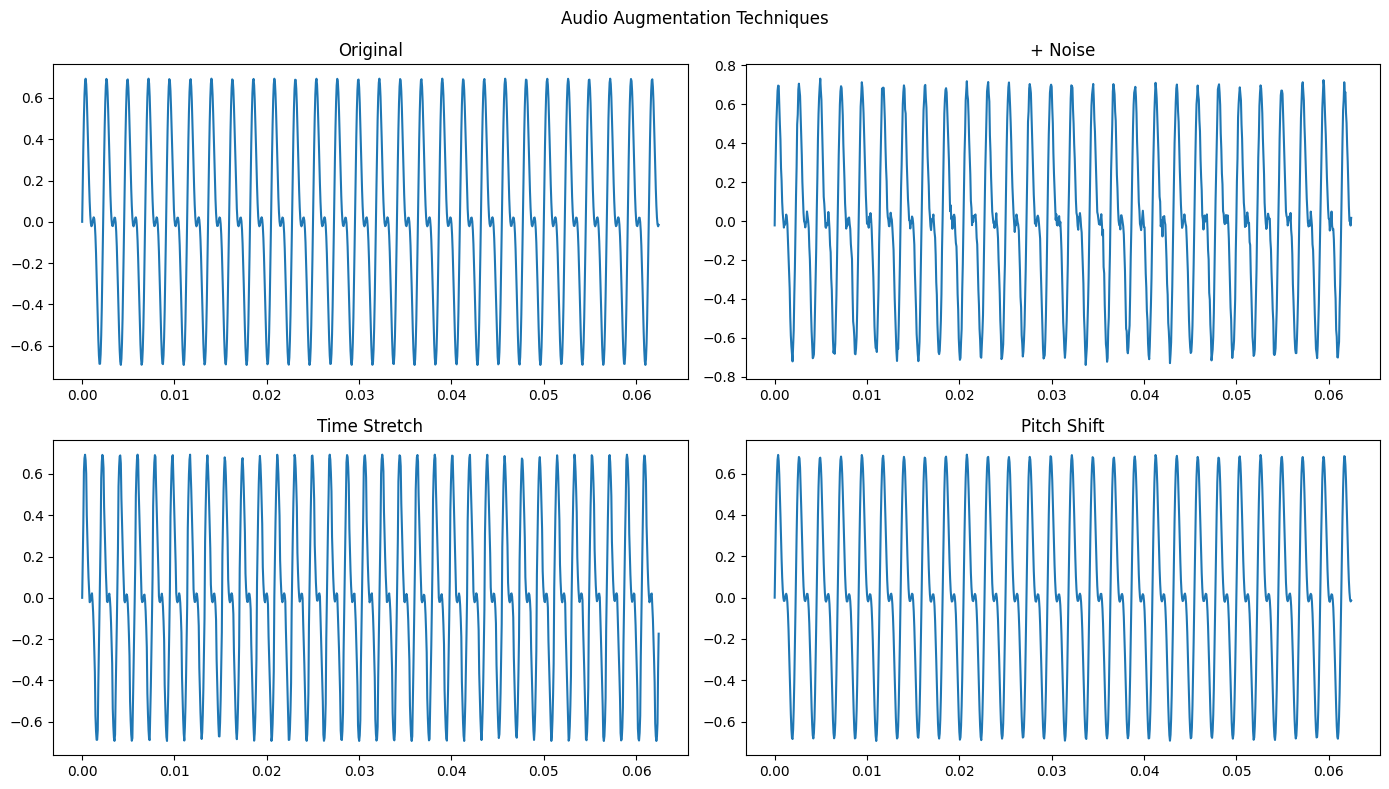

In [8]:
# Generate synthetic audio signal
sr = 16000
duration = 1.0
t_audio = np.linspace(0, duration, int(sr * duration))
audio_signal = 0.5 * np.sin(2 * np.pi * 440 * t_audio) + 0.3 * np.sin(2 * np.pi * 880 * t_audio)

# Manual augmentations
def add_noise(signal, noise_level=0.02):
    return signal + noise_level * np.random.randn(len(signal))

def time_stretch_simple(signal, rate=1.2):
    indices = np.round(np.arange(0, len(signal), rate)).astype(int)
    return signal[indices[indices < len(signal)]]

def pitch_shift_simple(signal, sr, steps=2):
    # Simple pitch shift via resampling
    factor = 2 ** (steps / 12)
    stretched = np.interp(np.arange(0, len(signal), factor),
                          np.arange(len(signal)), signal)
    # Resample back to original length
    return np.interp(np.linspace(0, len(stretched)-1, len(signal)),
                     np.arange(len(stretched)), stretched)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes[0,0].plot(t_audio[:1000], audio_signal[:1000]); axes[0,0].set_title('Original')
axes[0,1].plot(t_audio[:1000], add_noise(audio_signal)[:1000]); axes[0,1].set_title('+ Noise')
s = time_stretch_simple(audio_signal)
axes[1,0].plot(np.linspace(0, len(s)/sr, len(s))[:1000], s[:1000]); axes[1,0].set_title('Time Stretch')
ps = pitch_shift_simple(audio_signal, sr, steps=3)
axes[1,1].plot(t_audio[:1000], ps[:1000]); axes[1,1].set_title('Pitch Shift')
plt.suptitle('Audio Augmentation Techniques'); plt.tight_layout(); plt.show()

## Domain Summary
| Domain | Common Augmentations |
|---|---|
| **Image** | Flip, rotate, zoom, crop, color jitter, CutMix, MixUp |
| **Text** | Synonym replacement, random insertion/deletion, back-translation |
| **Time Series** | Jittering, scaling, time warping, window slicing |
| **Tabular** | SMOTE, noise injection, feature crossover |
| **Audio** | Noise injection, time stretch, pitch shift, SpecAugment |